In [1]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import re
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import matplotlib.dates as mdates
import pickle
import seaborn as sns
sns.set(style="whitegrid")


import platform
system_name = platform.system()
if system_name == 'Windows':
    plt.rcParams['font.sans-serif'] = ['SimHei']  # Windows 用黑体
elif system_name == 'Darwin':
    plt.rcParams['font.sans-serif'] = ['Arial Unicode MS'] # Mac 用 Arial Unicode

plt.rcParams['axes.unicode_minus'] = False # 解决负号显示问题

import warnings
from scipy.stats import ConstantInputWarning

warnings.filterwarnings("ignore", category=ConstantInputWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)

##########################################################################

def calc_ic(panel, factor_col, ret_col="ret_next"):
    df = panel[["date", factor_col, ret_col]].dropna()
    ic = df.groupby("date").apply(
        lambda x: x[factor_col].corr(x[ret_col], method="spearman")
    )
    ic.name = factor_col
    return ic

def ic_stats(ic):
    ic = ic.dropna()
    ic_mean = ic.mean()
    ic_std = ic.std()

    if pd.isna(ic_std) or ic_std == 0:
        tstat = np.nan
    else:
        tstat = ic_mean / ic_std * np.sqrt(len(ic))

    return pd.Series({
        "IC_mean": ic_mean,
        "IC_std": ic_std,
        "tstat": tstat,
        "N": len(ic)
    })

def csrank(x):
    return x.rank(pct=True) - 0.5



In [ ]:
##########################################################################

data = pd.read_csv(r"E:\26Spring\Final\code\data_with_event_bools.csv")

data = data.sort_values(["ticker", "date"]).copy()
data["date"] = pd.to_datetime(data["date"])
data["ret_next"] = data.groupby("ticker")["AdjClose"].shift(-1) / data["AdjClose"] - 1

data["year"] = data["date"].dt.year

liq_year = (
    data.groupby(["year", "ticker"])["amount"]
    .mean()
    .reset_index()
    .rename(columns={"amount": "liq"})
)

liq_year["threshold"] = (
    liq_year.groupby("year")["liq"]
    .transform(lambda x: x.quantile(0.8))
)

liq_top = liq_year[liq_year["liq"] >= liq_year["threshold"]]

data = data.merge(
    liq_top[["year", "ticker"]],
    on=["year", "ticker"],
    how="inner"
)

##########################################################################

ticker_counts = data.groupby('ticker').size().reset_index(name='rows')
ticker_counts_bb = data.groupby('ticker')['buyback_amount'].count().reset_index(name='rows')

merged = pd.merge(ticker_counts, ticker_counts_bb, on='ticker', how='left', suffixes=('_total', '_bb'))
merged["ratio"] = merged["rows_bb"] / merged["rows_total"]
merged.sort_values("ratio", ascending=False)

##########################################################################

merged['ratio_weight'] = merged['ratio'] / merged['ratio'].sum()
merged = merged.sort_values('ratio_weight', ascending=False)
merged['cum_weight'] = merged['ratio_weight'].cumsum()

top = merged[(merged['cum_weight'] <= 0.8) & (merged['rows_total'] > 100)]

top_tickers = top["ticker"].unique()
filtered_data = data[data["ticker"].isin(top_tickers)].copy()

##########################################################################

with pd.HDFStore(r'E:\26Spring\Final\data\hk_shares.h5') as store:
    shares = store.get(store.keys()[0]).reset_index()

shares["ticker"] = shares["order_book_id"].str[1:5] + ".hk"
shares["date"] = pd.to_datetime(shares["date"])

filtered_data["ticker"] = filtered_data["ticker"].str.lower()
filtered_data["date"] = pd.to_datetime(filtered_data["date"])

share_col = "total"  

shares_daily = (
    shares.sort_values("date")
    .groupby(["date", "ticker"], as_index=False)
    .last()
)

filtered_data = filtered_data.merge(
    shares_daily[["date", "ticker", share_col]].rename(columns={share_col: "shares_total"}),
    on=["date", "ticker"],
    how="left"
)

filtered_data["mktcp_new"] = filtered_data["close"] * filtered_data["shares_total"]

##########################################################################

filtered_data = filtered_data.sort_values(["ticker", "date"]).copy()

filtered_data["buyback_amount_filled"] = filtered_data["buyback_amount"].fillna(0)

filtered_data["buyback_1y"] = (
    filtered_data.groupby("ticker")["buyback_amount_filled"]
    .transform(lambda s: s.rolling(window=252, min_periods=1).sum())
)

filtered_data["buyback_2y"] = (
    filtered_data.groupby("ticker")["buyback_amount_filled"]
    .transform(lambda s: s.rolling(window=504, min_periods=1).sum())
)

filtered_data["buyback_3y"] = (
    filtered_data.groupby("ticker")["buyback_amount_filled"]
    .transform(lambda s: s.rolling(window=756, min_periods=1).sum())
)

filtered_data["bb_yield_1y"] = filtered_data["buyback_1y"] / filtered_data["mktcp_new"]
filtered_data["bb_yield_2y"] = filtered_data["buyback_2y"] / filtered_data["mktcp_new"]
filtered_data["bb_yield_3y"] = filtered_data["buyback_3y"] / filtered_data["mktcp_new"]

filtered_data["bb_share_1y"] = filtered_data["buyback_1y"] / filtered_data["AdjClose"] 
filtered_data["bb_share_2y"] = filtered_data["buyback_2y"] / filtered_data["AdjClose"]
filtered_data["bb_share_3y"] = filtered_data["buyback_3y"] / filtered_data["AdjClose"]



In [4]:
panel = filtered_data.sort_values(["date", "ticker"]).copy()

test_factors = [
    "bb_yield_1y",
    "bb_yield_2y",
    "bb_yield_3y",
    "bb_share_1y",
    "bb_share_2y",
    "bb_share_3y",
    "buyback_1y",
    "buyback_2y",
    "buyback_3y"
]

ic_summary = pd.concat(
    [ic_stats(calc_ic(panel, f, "ret_next")).rename(f) for f in test_factors],
    axis=1
).T

print(ic_summary.sort_values("IC_mean", ascending=False))

              IC_mean    IC_std     tstat       N
buyback_1y   0.010349  0.356438  1.488378  2628.0
buyback_2y   0.009854  0.347516  1.453669  2628.0
bb_share_1y  0.008158  0.360046  1.161553  2628.0
bb_yield_1y  0.007477  0.348574  1.099554  2628.0
buyback_3y   0.006636  0.346115  0.982926  2628.0
bb_yield_2y  0.005143  0.339266  0.777133  2628.0
bb_share_2y  0.005027  0.353018  0.729994  2628.0
bb_share_3y  0.003319  0.353872  0.480794  2628.0
bb_yield_3y  0.003292  0.341820  0.493683  2628.0


In [5]:
##########################################################################
# 1. 一些增强函数
##########################################################################

def winsorize_by_date(df, col, lower=0.01, upper=0.99):
    df = df.copy()
    q = df.groupby("date")[col].transform(
        lambda x: x.quantile(lower)
    )
    q2 = df.groupby("date")[col].transform(
        lambda x: x.quantile(upper)
    )
    df[col + "_win"] = df[col].clip(q, q2)
    return df

def add_csrank_factor(df, col):
    df = df.copy()
    df[col + "_rank"] = df.groupby("date")[col].transform(csrank)
    return df

def add_zscore_factor(df, col):
    df = df.copy()
    df[col + "_z"] = df.groupby("date")[col].transform(
        lambda x: (x - x.mean()) / x.std() if x.std() != 0 else np.nan
    )
    return df

##########################################################################
# 2. 对原始最强信号做增强
##########################################################################

enhanced = panel.copy()

base_cols = ["buyback_1y", "buyback_2y", "buyback_3y"]

for col in base_cols:
    enhanced = winsorize_by_date(enhanced, col, 0.01, 0.99)
    enhanced[f"log_{col}"] = np.log1p(enhanced[col])
    enhanced[f"log_{col}_win"] = np.log1p(enhanced[f"{col}_win"])
    
    enhanced = add_csrank_factor(enhanced, col)
    enhanced = add_csrank_factor(enhanced, f"{col}_win")
    enhanced = add_csrank_factor(enhanced, f"log_{col}")
    enhanced = add_csrank_factor(enhanced, f"log_{col}_win")

##########################################################################
# 3. 增量 / 加速度型因子
##########################################################################

enhanced["buyback_1y_delta"] = enhanced["buyback_1y"] - enhanced["buyback_2y"] / 2
enhanced["buyback_2y_delta"] = enhanced["buyback_2y"] - enhanced["buyback_3y"] * (2/3)

enhanced["buyback_1y_to_3y"] = enhanced["buyback_1y"] / (enhanced["buyback_3y"] + 1e-8)
enhanced["buyback_1y_to_2y"] = enhanced["buyback_1y"] / (enhanced["buyback_2y"] + 1e-8)

for col in ["buyback_1y_delta", "buyback_2y_delta", "buyback_1y_to_3y", "buyback_1y_to_2y"]:
    enhanced = winsorize_by_date(enhanced, col, 0.01, 0.99)
    enhanced[f"log_{col}_win"] = np.sign(enhanced[f"{col}_win"]) * np.log1p(np.abs(enhanced[f"{col}_win"]))
    enhanced = add_csrank_factor(enhanced, f"{col}_win")
    enhanced = add_csrank_factor(enhanced, f"log_{col}_win")

In [6]:
##########################################################################
# 4. 事件增强型因子
##########################################################################

event_cols = [
    "hit_execution",
    "hit_nextday",
    "hit_completion",
    "has_any_event"
]

for e in event_cols:
    enhanced[f"buyback_3y_x_{e}"] = enhanced["buyback_3y"] * enhanced[e].astype(int)
    enhanced[f"log_buyback_3y_x_{e}"] = np.log1p(enhanced[f"buyback_3y_x_{e}"])

enhanced["buyback_3y_x_n_ann"] = enhanced["buyback_3y"] * enhanced["n_repurchase_announcements"]
enhanced["log_buyback_3y_x_n_ann"] = np.log1p(enhanced["buyback_3y_x_n_ann"])

for col in [
    "buyback_3y_x_hit_execution",
    "buyback_3y_x_hit_nextday",
    "buyback_3y_x_hit_completion",
    "buyback_3y_x_has_any_event",
    "buyback_3y_x_n_ann",
    "log_buyback_3y_x_hit_execution",
    "log_buyback_3y_x_hit_nextday",
    "log_buyback_3y_x_hit_completion",
    "log_buyback_3y_x_has_any_event",
    "log_buyback_3y_x_n_ann"
]:
    enhanced = add_csrank_factor(enhanced, col)

In [7]:
##########################################################################
# 5. 横截面残差化（去规模/价格暴露）
##########################################################################

def cs_residualize(df, y_col, x_cols, out_col):
    def _regress(g):
        tmp = g[[y_col] + x_cols].replace([np.inf, -np.inf], np.nan).dropna()
        if len(tmp) < max(20, len(x_cols) + 5):
            g[out_col] = np.nan
            return g
        
        X = tmp[x_cols].copy()
        X = X.astype(float)
        X["const"] = 1.0
        y = tmp[y_col].astype(float)

        beta = np.linalg.lstsq(X.values, y.values, rcond=None)[0]
        y_hat = X.values @ beta
        resid = y.values - y_hat

        g[out_col] = np.nan
        g.loc[tmp.index, out_col] = resid
        return g

    return df.groupby("date", group_keys=False).apply(_regress)

enhanced["log_mktcp"] = np.log(enhanced["mktcp_new"].replace(0, np.nan))
enhanced["log_price"] = np.log(enhanced["AdjClose"].replace(0, np.nan))

# 只去规模
enhanced = cs_residualize(
    enhanced,
    y_col="log_buyback_3y",
    x_cols=["log_mktcp"],
    out_col="log_buyback_3y_resid_size"
)

# 去规模 + 价格
enhanced = cs_residualize(
    enhanced,
    y_col="log_buyback_3y",
    x_cols=["log_mktcp", "log_price"],
    out_col="log_buyback_3y_resid_size_price"
)

enhanced = add_csrank_factor(enhanced, "log_buyback_3y_resid_size")
enhanced = add_csrank_factor(enhanced, "log_buyback_3y_resid_size_price")

In [8]:
##########################################################################
# 6. 统一 IC 测试
##########################################################################

new_test_factors = [
    # 原始增强
    "buyback_1y_rank",
    "buyback_2y_rank",
    "buyback_3y_rank",
    "buyback_1y_win_rank",
    "buyback_2y_win_rank",
    "buyback_3y_win_rank",
    "log_buyback_1y_rank",
    "log_buyback_2y_rank",
    "log_buyback_3y_rank",
    "log_buyback_1y_win_rank",
    "log_buyback_2y_win_rank",
    "log_buyback_3y_win_rank",

    # 增量/加速度
    "buyback_1y_delta_win_rank",
    "buyback_2y_delta_win_rank",
    "log_buyback_1y_delta_win_rank",
    "log_buyback_2y_delta_win_rank",
    "buyback_1y_to_3y_win_rank",
    "buyback_1y_to_2y_win_rank",
    "log_buyback_1y_to_3y_win_rank",
    "log_buyback_1y_to_2y_win_rank",

    # 事件增强
    "buyback_3y_x_hit_execution_rank",
    "buyback_3y_x_hit_nextday_rank",
    "buyback_3y_x_hit_completion_rank",
    "buyback_3y_x_has_any_event_rank",
    "buyback_3y_x_n_ann_rank",
    "log_buyback_3y_x_hit_execution_rank",
    "log_buyback_3y_x_hit_nextday_rank",
    "log_buyback_3y_x_hit_completion_rank",
    "log_buyback_3y_x_has_any_event_rank",
    "log_buyback_3y_x_n_ann_rank",

    # 残差化
    "log_buyback_3y_resid_size_rank",
    "log_buyback_3y_resid_size_price_rank"
]

ic_summary_new = pd.concat(
    [ic_stats(calc_ic(enhanced, f, "ret_next")).rename(f) for f in new_test_factors],
    axis=1
).T


In [9]:
display(ic_summary_new.sort_values("IC_mean", ascending=False))

,IC_mean,IC_std,tstat,N
log_buyback_3y_x_hit_completion_rank,0.146135,0.296617,2.606978,28.0
buyback_3y_x_hit_completion_rank,0.146135,0.296617,2.606978,28.0
log_buyback_3y_x_n_ann_rank,0.023451,0.351684,2.727442,1673.0
buyback_3y_x_n_ann_rank,0.023451,0.351684,2.727442,1673.0
buyback_3y_x_hit_nextday_rank,0.023401,0.348400,2.707643,1625.0
log_buyback_3y_x_hit_nextday_rank,0.023401,0.348400,2.707643,1625.0
log_buyback_3y_x_has_any_event_rank,0.022826,0.351515,2.655278,1672.0
buyback_3y_x_has_any_event_rank,0.022826,0.351515,2.655278,1672.0
log_buyback_3y_x_hit_execution_rank,0.022010,0.350501,2.562399,1665.0
buyback_3y_x_hit_execution_rank,0.022010,0.350501,2.562399,1665.0


In [10]:
##########################################################################
# 7. 简单分组回测（top-bottom）
##########################################################################

def simple_ls_backtest(panel, factor_col, ret_col="ret_next", q=5):
    df = panel[["date", factor_col, ret_col]].dropna().copy()
    
    def one_day(g):
        if g[factor_col].nunique() < q:
            return np.nan
        g["bucket"] = pd.qcut(g[factor_col].rank(method="first"), q, labels=False)
        long_ret = g.loc[g["bucket"] == q - 1, ret_col].mean()
        short_ret = g.loc[g["bucket"] == 0, ret_col].mean()
        return long_ret - short_ret

    ls = df.groupby("date").apply(one_day)
    return ls

candidate_factors = [
    "buyback_3y",
    "log_buyback_3y_win_rank",
    "log_buyback_3y_resid_size_rank",
    "log_buyback_3y_resid_size_price_rank",
    "log_buyback_3y_x_hit_execution_rank",
    "log_buyback_1y_to_3y_win_rank"
]

bt_stats = []
for f in candidate_factors:
    ls = simple_ls_backtest(enhanced, f)
    bt_stats.append(pd.Series({
        "factor": f,
        "mean_daily_ls": ls.mean(),
        "std_daily_ls": ls.std(),
        "tstat": ls.mean() / ls.std() * np.sqrt(ls.dropna().shape[0]) if ls.std() != 0 else np.nan,
        "n_days": ls.dropna().shape[0]
    }))

bt_stats = pd.DataFrame(bt_stats).sort_values("mean_daily_ls", ascending=False)
display(bt_stats)

,factor,mean_daily_ls,std_daily_ls,tstat,n_days
5,log_buyback_1y_to_3y_win_rank,0.000328,0.019145,0.713846,1738
0,buyback_3y,-0.000335,0.020275,-0.754246,2084
1,log_buyback_3y_win_rank,-0.000335,0.020275,-0.754246,2084
4,log_buyback_3y_x_hit_execution_rank,-0.000787,0.024512,-0.890988,770
3,log_buyback_3y_resid_size_price_rank,-0.001314,0.016458,-1.079908,183
2,log_buyback_3y_resid_size_rank,-0.001807,0.016026,-1.525580,183


In [11]:
##########################################################################
# A. 事件 dummy 自身是否已经有 alpha？
##########################################################################

event_test_cols = [
    "hit_nextday",
    "hit_execution",
    "hit_completion",
    "has_any_event",
    "n_repurchase_announcements"
]

event_ic_summary = pd.concat(
    [ic_stats(calc_ic(enhanced, c, "ret_next")).rename(c) for c in event_test_cols],
    axis=1
).T

display(event_ic_summary.sort_values("IC_mean", ascending=False))

,IC_mean,IC_std,tstat,N
hit_completion,0.123611,0.295831,2.363682,32.0
hit_nextday,0.026151,0.353443,2.987185,1630.0
n_repurchase_announcements,0.024792,0.356396,2.858009,1688.0
has_any_event,0.024034,0.356582,2.767495,1686.0
hit_execution,0.023109,0.356190,2.657646,1678.0


In [12]:
##########################################################################
# B1. 在 hit_nextday == 1 的样本内部，验证 buyback_3y 是否仍然有效
##########################################################################

nextday_only = enhanced[enhanced["hit_nextday"] == True].copy()

nextday_ic_summary = pd.concat(
    [
        ic_stats(calc_ic(nextday_only, "buyback_3y", "ret_next")).rename("buyback_3y_in_nextday"),
        ic_stats(calc_ic(nextday_only, "log_buyback_3y", "ret_next")).rename("log_buyback_3y_in_nextday"),
    ],
    axis=1
).T

display(nextday_ic_summary)

,IC_mean,IC_std,tstat,N
buyback_3y_in_nextday,-0.034202,0.639978,-1.748124,1070.0
log_buyback_3y_in_nextday,-0.034202,0.639978,-1.748124,1070.0


In [13]:
##########################################################################
# B2. 在 hit_execution == 1 的样本内部，验证 buyback_3y 是否仍然有效
##########################################################################

execution_only = enhanced[enhanced["hit_execution"] == True].copy()

execution_ic_summary = pd.concat(
    [
        ic_stats(calc_ic(execution_only, "buyback_3y", "ret_next")).rename("buyback_3y_in_execution"),
        ic_stats(calc_ic(execution_only, "log_buyback_3y", "ret_next")).rename("log_buyback_3y_in_execution"),
    ],
    axis=1
).T

display(execution_ic_summary)

,IC_mean,IC_std,tstat,N
buyback_3y_in_execution,-0.035678,0.637061,-1.865889,1110.0
log_buyback_3y_in_execution,-0.035678,0.637061,-1.865889,1110.0


In [14]:
##########################################################################
# C1. 控制 hit_nextday 后，看 buyback_3y 是否还有独立信息
##########################################################################

def cs_residualize_simple(df, y_col, x_cols, out_col):
    def _reg(g):
        tmp = g[[y_col] + x_cols].replace([np.inf, -np.inf], np.nan).dropna()
        if len(tmp) < max(20, len(x_cols) + 5):
            g[out_col] = np.nan
            return g

        X = tmp[x_cols].astype(float).copy()
        X["const"] = 1.0
        y = tmp[y_col].astype(float)

        beta = np.linalg.lstsq(X.values, y.values, rcond=None)[0]
        resid = y.values - X.values @ beta

        g[out_col] = np.nan
        g.loc[tmp.index, out_col] = resid
        return g

    return df.groupby("date", group_keys=False).apply(_reg)

enhanced["hit_nextday_int"] = enhanced["hit_nextday"].astype(int)
enhanced["hit_execution_int"] = enhanced["hit_execution"].astype(int)

enhanced = cs_residualize_simple(
    enhanced,
    y_col="log_buyback_3y_x_hit_nextday",
    x_cols=["hit_nextday_int"],
    out_col="log_buyback_3y_x_hit_nextday_resid"
)

enhanced = cs_residualize_simple(
    enhanced,
    y_col="log_buyback_3y_x_hit_execution",
    x_cols=["hit_execution_int"],
    out_col="log_buyback_3y_x_hit_execution_resid"
)

enhanced = add_csrank_factor(enhanced, "log_buyback_3y_x_hit_nextday_resid")
enhanced = add_csrank_factor(enhanced, "log_buyback_3y_x_hit_execution_resid")

resid_ic_summary = pd.concat(
    [
        ic_stats(calc_ic(enhanced, "log_buyback_3y_x_hit_nextday_resid_rank", "ret_next")).rename("nextday_resid_rank"),
        ic_stats(calc_ic(enhanced, "log_buyback_3y_x_hit_execution_resid_rank", "ret_next")).rename("execution_resid_rank"),
    ],
    axis=1
).T

display(resid_ic_summary)

,IC_mean,IC_std,tstat,N
nextday_resid_rank,0.026461,0.292064,1.225620,183.0
execution_resid_rank,0.027926,0.288618,1.308919,183.0


In [15]:
##########################################################################
# D. 分年稳定性
##########################################################################

def yearly_ic_table(panel, factor_col, ret_col="ret_next"):
    df = panel[["date", "year", factor_col, ret_col]].dropna().copy()
    out = (
        df.groupby("year")
        .apply(lambda x: x.groupby("date").apply(
            lambda g: g[factor_col].corr(g[ret_col], method="spearman")
        ).mean())
        .rename("IC_mean")
        .to_frame()
    )
    return out

yearly_nextday = yearly_ic_table(enhanced, "buyback_3y_x_hit_nextday_rank")
yearly_execution = yearly_ic_table(enhanced, "buyback_3y_x_hit_execution_rank")

print("=== yearly IC: nextday ===")
display(yearly_nextday)

print("=== yearly IC: execution ===")
display(yearly_execution)

=== yearly IC: nextday ===


,IC_mean
year,
2015,0.032981
2016,0.050790
2017,0.021340
2018,-0.002859
2019,0.042256
2020,-0.082479
2021,0.027550
2022,0.046142
2023,0.038572


=== yearly IC: execution ===


,IC_mean
year,
2015,0.027148
2016,0.044705
2017,0.023550
2018,-0.001330
2019,0.024376
2020,0.140653
2021,0.036198
2022,0.045718
2023,0.032846


In [16]:
##########################################################################
# E. 简单时间切分 OOS 验证
##########################################################################

all_dates = sorted(enhanced["date"].dropna().unique())
split_idx = int(len(all_dates) * 0.7)
train_end = all_dates[split_idx]

train = enhanced[enhanced["date"] <= train_end].copy()
test  = enhanced[enhanced["date"] > train_end].copy()

oos_factors = [
    "buyback_3y_x_hit_nextday_rank",
    "buyback_3y_x_hit_execution_rank",
    "buyback_3y"
]

oos_summary = []

for f in oos_factors:
    train_ic = calc_ic(train, f, "ret_next")
    test_ic  = calc_ic(test, f, "ret_next")

    oos_summary.append(pd.Series({
        "factor": f,
        "train_IC_mean": train_ic.mean(),
        "test_IC_mean": test_ic.mean(),
        "train_tstat": ic_stats(train_ic)["tstat"],
        "test_tstat": ic_stats(test_ic)["tstat"],
        "train_N": ic_stats(train_ic)["N"],
        "test_N": ic_stats(test_ic)["N"]
    }))

oos_summary = pd.DataFrame(oos_summary).sort_values("test_IC_mean", ascending=False)
display(oos_summary)

,factor,train_IC_mean,test_IC_mean,train_tstat,test_tstat,train_N,test_N
2,buyback_3y,0.003287,0.014402,0.382939,1.398162,1836.0,792.0
0,buyback_3y_x_hit_nextday_rank,0.031852,0.014157,2.473230,1.246336,849.0,776.0
1,buyback_3y_x_hit_execution_rank,0.031097,0.011626,2.451635,1.025160,888.0,777.0


In [17]:
##########################################################################
# 在原始 data（非 filtered_data）上测试 event dummy 的预测能力
##########################################################################

full_panel = data.sort_values(["date", "ticker"]).copy()

event_test_cols = [
    "hit_nextday",
    "hit_execution",
    "hit_completion",
    "has_any_event",
    "n_repurchase_announcements"
]

full_event_ic_summary = pd.concat(
    [ic_stats(calc_ic(full_panel, c, "ret_next")).rename(c) for c in event_test_cols],
    axis=1
).T

display(full_event_ic_summary.sort_values("IC_mean", ascending=False))

,IC_mean,IC_std,tstat,N
hit_completion,0.023442,0.100619,1.935236,69.0
n_repurchase_announcements,0.015985,0.110749,6.626806,2108.0
has_any_event,0.015742,0.110813,6.514545,2103.0
hit_nextday,0.015387,0.111896,6.009607,1910.0
hit_execution,0.015381,0.110790,6.308771,2065.0


In [18]:
##########################################################################
# 原始 data vs filtered_data 的 event dummy 预测力对比
##########################################################################

filtered_panel = filtered_data.sort_values(["date", "ticker"]).copy()

compare_rows = []

for c in event_test_cols:
    ic_full = calc_ic(full_panel, c, "ret_next")
    ic_filt = calc_ic(filtered_panel, c, "ret_next")
    
    stat_full = ic_stats(ic_full)
    stat_filt = ic_stats(ic_filt)
    
    compare_rows.append(pd.Series({
        "factor": c,
        "full_IC_mean": stat_full["IC_mean"],
        "full_tstat": stat_full["tstat"],
        "full_N": stat_full["N"],
        "filtered_IC_mean": stat_filt["IC_mean"],
        "filtered_tstat": stat_filt["tstat"],
        "filtered_N": stat_filt["N"],
        "IC_lift_filtered_minus_full": stat_filt["IC_mean"] - stat_full["IC_mean"]
    }))

event_compare = pd.DataFrame(compare_rows).sort_values("filtered_IC_mean", ascending=False)
display(event_compare)

,factor,full_IC_mean,full_tstat,full_N,filtered_IC_mean,filtered_tstat,filtered_N,IC_lift_filtered_minus_full
2,hit_completion,0.023442,1.935236,69.0,0.123611,2.363682,32.0,0.100169
0,hit_nextday,0.015387,6.009607,1910.0,0.026151,2.987185,1630.0,0.010764
4,n_repurchase_announcements,0.015985,6.626806,2108.0,0.024792,2.858009,1688.0,0.008807
3,has_any_event,0.015742,6.514545,2103.0,0.024034,2.767495,1686.0,0.008292
1,hit_execution,0.015381,6.308771,2065.0,0.023109,2.657646,1678.0,0.007728


In [19]:
##########################################################################
# 原始 data vs filtered_data 的事件发生率对比
##########################################################################

event_freq_compare = []

for c in ["hit_nextday", "hit_execution", "hit_completion", "has_any_event"]:
    event_freq_compare.append(pd.Series({
        "factor": c,
        "full_event_rate": data[c].mean(),
        "filtered_event_rate": filtered_data[c].mean(),
        "rate_diff": filtered_data[c].mean() - data[c].mean()
    }))

event_freq_compare.append(pd.Series({
    "factor": "n_repurchase_announcements",
    "full_event_rate": data["n_repurchase_announcements"].mean(),
    "filtered_event_rate": filtered_data["n_repurchase_announcements"].mean(),
    "rate_diff": filtered_data["n_repurchase_announcements"].mean() - data["n_repurchase_announcements"].mean()
}))

event_freq_compare = pd.DataFrame(event_freq_compare)
display(event_freq_compare)

,factor,full_event_rate,filtered_event_rate,rate_diff
0,hit_nextday,0.034506,0.249363,0.214857
1,hit_execution,0.038521,0.259628,0.221107
2,hit_completion,0.000251,0.001093,0.000842
3,has_any_event,0.039525,0.261549,0.222024
4,n_repurchase_announcements,0.039805,0.263039,0.223235


不同时间尺度下的收益率指标

In [20]:
def add_forward_returns(df, price_col="AdjClose", horizons=range(1, 61)):
    df = df.sort_values(["ticker", "date"]).copy()
    
    for h in horizons:
        df[f"ret_fwd_{h}"] = (
            df.groupby("ticker")[price_col]
            .shift(-h) / df[price_col] - 1
        )
    
    return df

enhanced = add_forward_returns(enhanced, price_col="AdjClose")


In [21]:
horizons = range(1, 61)
event_cols = [
    "hit_nextday",
    "hit_execution",
    "has_any_event"
]

results = []

for f in event_cols:
    for h in horizons:
        ic = calc_ic(enhanced, f, f"ret_fwd_{h}")
        stat = ic_stats(ic)
        
        results.append(pd.Series({
            "factor": f,
            "horizon": h,
            "IC_mean": stat["IC_mean"],
            "tstat": stat["tstat"],
            "N": stat["N"]
        }))

horizon_ic = pd.DataFrame(results)
display(horizon_ic.sort_values(["factor", "horizon"]))

,factor,horizon,IC_mean,tstat,N
120,has_any_event,1,0.024185,2.785940,1686.0
121,has_any_event,2,0.020301,2.347744,1685.0
122,has_any_event,3,0.017148,1.988189,1684.0
123,has_any_event,4,0.016148,1.883099,1683.0
124,has_any_event,5,0.013381,1.553729,1683.0
...,...,...,...,...,...
55,hit_nextday,56,0.065894,7.365600,1572.0
56,hit_nextday,57,0.066384,7.423195,1571.0
57,hit_nextday,58,0.065980,7.355826,1570.0
58,hit_nextday,59,0.069279,7.761021,1569.0


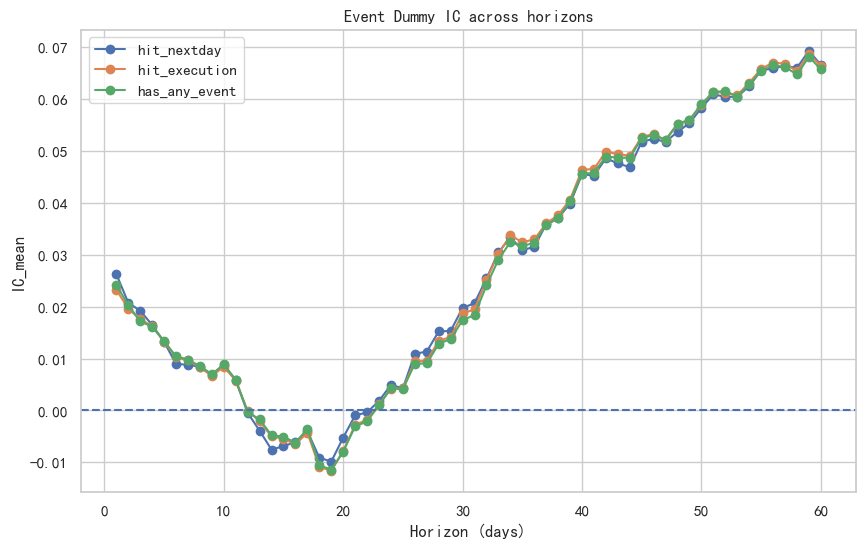

In [22]:
plt.figure(figsize=(10,6))

for f in event_cols:
    tmp = horizon_ic[horizon_ic["factor"] == f]
    plt.plot(tmp["horizon"], tmp["IC_mean"], marker="o", label=f)

plt.axhline(0, linestyle="--")
plt.xlabel("Horizon (days)")
plt.ylabel("IC_mean")
plt.title("Event Dummy IC across horizons")
plt.legend()
plt.show()

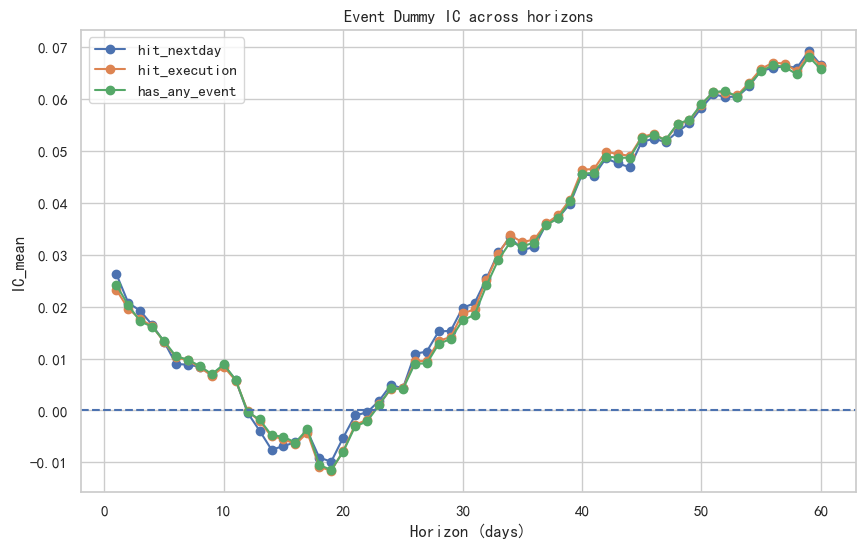

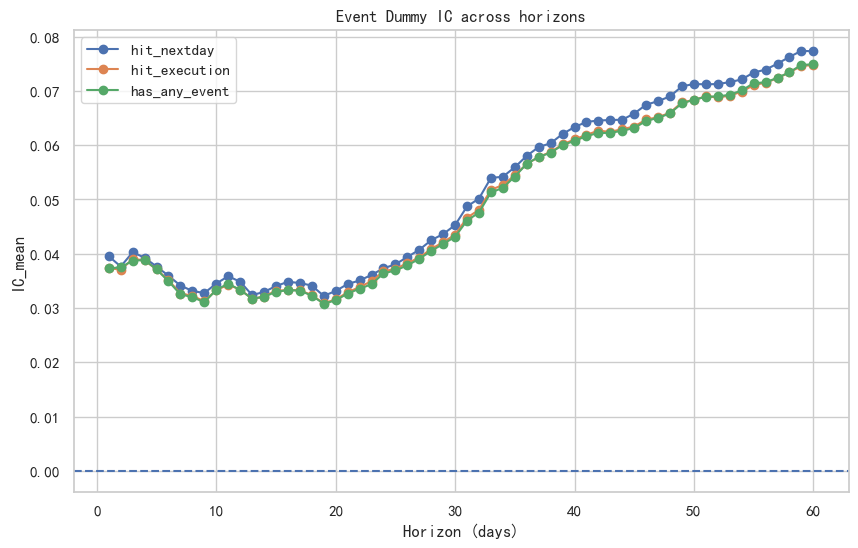

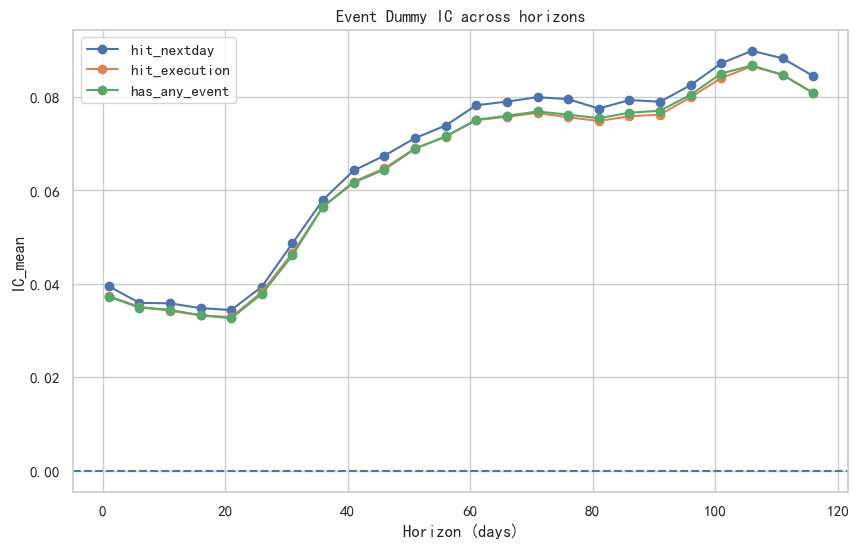